In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

sys.path.insert(1, '../utils')
from sklearn.feature_selection import mutual_info_regression as MI

from utils import * 
from plotUtils import *
from fcMeasure import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
def sort_filesK(files):
    # sorting based on K value

    Karr_cv = []
    Karr_lyap = []

    _resultsLyap = []
    _resultsCV = []

    for _file in files:
        basename = os.path.basename(_file).split('.pkl')[0]
        _type = basename.split('_')[-1]
        K = float(basename.split('_')[-2])

        if _type == 'cv':
            Karr_cv.append(K)
            _resultsCV.append(_file)
        
        elif _type == 'lyap':
            Karr_lyap.append(K)
            _resultsLyap.append(_file)

    Karr_cv = np.array(Karr_cv)
    Karr_lyap = np.array(Karr_lyap)

    _resultsLyap = np.array(_resultsLyap)
    _resultsCV = np.array(_resultsCV)

    Ksort_cv = np.argsort(Karr_cv)
    Ksort_lyap = np.argsort(Karr_lyap)

    _resultsLyap = _resultsLyap[Ksort_lyap]
    _resultsCV = _resultsCV[Ksort_cv]

    return _resultsLyap, _resultsCV, Karr_lyap[Ksort_lyap]

In [3]:
def sort_filesI(files):
    # sorting based on I value

    Iarr_cv = []
    Iarr_lyap = []

    _resultsLyap = []
    _resultsCV = []

    for _file in files:
        basename = os.path.basename(_file).split('.pkl')[0]
        _type = basename.split('_')[-1]
        I = float(basename.split('_')[1].split('mV')[0])

        if _type == 'cv':
            Iarr_cv.append(I)
            _resultsCV.append(_file)
        
        elif _type == 'lyap':
            Iarr_lyap.append(I)
            _resultsLyap.append(_file)

    Iarr_cv = np.array(Iarr_cv)
    Iarr_lyap = np.array(Iarr_lyap)

    _resultsLyap = np.array(_resultsLyap)
    _resultsCV = np.array(_resultsCV)

    Isort_cv = np.argsort(Iarr_cv)
    Isort_lyap = np.argsort(Iarr_lyap)

    _resultsLyap = _resultsLyap[Isort_lyap]
    _resultsCV = _resultsCV[Isort_cv]

    return _resultsLyap, _resultsCV, Iarr_lyap[Isort_lyap]

In [4]:
def lyapunov_plot_arr(_filesLyap, Xvals, sige = [0, 2], sigi = [1, -1]):
    modLyap_mean = np.zeros((4, len(Xvals)))
    modLyap_var = np.zeros((4, len(Xvals)))
    Nbar = 9

    nonmodLyap_mean = np.zeros((Nbar, 4, len(Xvals)))
    nonmodLyap_var = np.zeros((Nbar, 4, len(Xvals)))

    for nf, _file in enumerate(_filesLyap):
        _lyapDict = pickle.load(open(_file, "rb"))

        modLyap_mean[0, nf] = _lyapDict["mod_node"][sige[0], sigi[0]]
        modLyap_mean[1, nf] = _lyapDict["mod_node"][sige[0], sigi[-1]]
        modLyap_mean[2, nf] = _lyapDict["mod_node"][sige[-1], sigi[0]]
        modLyap_mean[3, nf] = _lyapDict["mod_node"][sige[-1], sigi[-1]]

        modLyap_var[0, nf] = _lyapDict["mod_node_var"][sige[0], sigi[0]]
        modLyap_var[1, nf] = _lyapDict["mod_node_var"][sige[0], sigi[-1]]
        modLyap_var[2, nf] = _lyapDict["mod_node_var"][sige[-1], sigi[0]]
        modLyap_var[3, nf] = _lyapDict["mod_node_var"][sige[-1], sigi[-1]]

        nonmodLyap_mean[:, 0, nf] = _lyapDict["nonmod_nodes"][:, sige[0], sigi[0]]
        nonmodLyap_mean[:, 1, nf] = _lyapDict["nonmod_nodes"][:, sige[0], sigi[-1]]
        nonmodLyap_mean[:, 2, nf] = _lyapDict["nonmod_nodes"][:, sige[-1], sigi[0]]
        nonmodLyap_mean[:, 3, nf] = _lyapDict["nonmod_nodes"][:, sige[-1], sigi[-1]]

        nonmodLyap_var[:, 0, nf] = _lyapDict["nonmod_nodes_var"][:, sige[0], sigi[0]]
        nonmodLyap_var[:, 1, nf] = _lyapDict["nonmod_nodes_var"][:, sige[0], sigi[-1]]
        nonmodLyap_var[:, 2, nf] = _lyapDict["nonmod_nodes_var"][:, sige[-1], sigi[0]]
        nonmodLyap_var[:, 3, nf] = _lyapDict["nonmod_nodes_var"][:, sige[-1], sigi[-1]]

    
    subINF_mod = -10 if len(modLyap_mean[~np.isinf(abs(modLyap_mean))].flatten()) == 0 else min(-10, min(modLyap_mean[~np.isinf(abs(modLyap_mean))]))
    subINF_nonmod = -10 if len(nonmodLyap_mean[~np.isinf(abs(nonmodLyap_mean))].flatten()) == 0 else min(-10, min(nonmodLyap_mean[~np.isinf(abs(nonmodLyap_mean))]))

    modLyap_mean[np.isinf(abs(modLyap_mean))] = subINF_mod
    modLyap_var[np.isnan(modLyap_var)] = 0.0

    for n in range(Nbar):
        nodeMat = nonmodLyap_mean[n, :, :]
        nodeMatv = nonmodLyap_var[n, :, :]
        subINF_nonmod = -10 if len(nodeMat[~np.isinf(abs(nodeMat))].flatten()) == 0 else min(-10, min(nodeMat[~np.isinf(abs(nodeMat))]))

        nodeMat[np.isinf(abs(nodeMat))] = subINF_nonmod
        nodeMatv[np.isnan(abs(nodeMatv))] = 0.0

        nonmodLyap_mean[n, :, :] = nodeMat
        nonmodLyap_var[n, :, :] = nodeMatv

    return modLyap_mean, modLyap_var, nonmodLyap_mean, nonmodLyap_var

In [5]:
def cv_plot_arr(_filesCV, Xvals, sige = [0, 2], sigi = [1, -1]):
    cvMean = np.zeros((4, len(Xvals)))
    cvVar = np.zeros((4, len(Xvals)))
    N = 10
    MeanMean = np.zeros((N, 4, len(Xvals)))
    MeanVar = np.zeros((N, 4, len(Xvals)))
    VarMean = np.zeros((N, 4, len(Xvals)))
    VarVar = np.zeros((N, 4, len(Xvals)))

    for nf, _file in enumerate(_filesCV):
        _cv = pickle.load(open(_file, "rb"))
        _cvMean = abs(_cv["mean_cv"])
        _cvVar = _cv["var_cv"]

        cvMean[0, nf] = _cvMean[sige[0], sigi[0]]; cvVar[0, nf] = _cvVar[sige[0], sigi[0]]
        cvMean[1, nf] = _cvMean[sige[0], sigi[-1]]; cvVar[1, nf] = _cvVar[sige[0], sigi[-1]]
        cvMean[2, nf] = _cvMean[sige[-1], sigi[0]]; cvVar[2, nf] = _cvVar[sige[-1], sigi[0]]
        cvMean[3, nf] = _cvMean[sige[-1], sigi[-1]]; cvVar[3, nf] = _cvVar[sige[-1], sigi[-1]]

        MeanMean[:, 0, nf] = _cv["mean_mean"][:, sige[0], sigi[0]]
        MeanMean[:, 1, nf] = _cv["mean_mean"][:, sige[0], sigi[-1]]
        MeanMean[:, 2, nf] = _cv["mean_mean"][:, sige[-1], sigi[0]]
        MeanMean[:, 3, nf] = _cv["mean_mean"][:, sige[-1], sigi[-1]]

        VarMean[:, 0, nf] = _cv["var_mean"][:, sige[0], sigi[0]]
        VarMean[:, 1, nf] = _cv["var_mean"][:, sige[0], sigi[-1]]
        VarMean[:, 2, nf] = _cv["var_mean"][:, sige[-1], sigi[0]]
        VarMean[:, 3, nf] = _cv["var_mean"][:, sige[-1], sigi[-1]]

        MeanVar[:, 0, nf] = _cv["mean_var"][:, sige[0], sigi[0]]
        MeanVar[:, 1, nf] = _cv["mean_var"][:, sige[0], sigi[-1]]
        MeanVar[:, 2, nf] = _cv["mean_var"][:, sige[-1], sigi[0]]
        MeanVar[:, 3, nf] = _cv["mean_var"][:, sige[-1], sigi[-1]]

        VarVar[:, 0, nf] = _cv["var_var"][:, sige[0], sigi[0]]
        VarVar[:, 1, nf] = _cv["var_var"][:, sige[0], sigi[-1]]
        VarVar[:, 2, nf] = _cv["var_var"][:, sige[-1], sigi[0]]
        VarVar[:, 3, nf] = _cv["var_var"][:, sige[-1], sigi[-1]]
    
    return cvMean, cvVar, MeanMean, MeanVar, VarMean, VarVar

In [6]:
def meanvarplot(response_map, Xarr, M = 1, Ylabel=r"$K_\mathrm{glob}$", figsize=(6,4), offset=5, nNodes = 10, variable = r"$\mu_u$", figroot = None, filename=None):
    pSige = [2.5, 7.5]
    pSigi = [4.4, 16.5]
    _colors = ["Blues", "Greens", "Reds", "Purples"]
    colors = ["b", "g", "r", "purple"]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True, layout="constrained")

    nRow = 0; nCol = 0
    for k in range(4):
        pcol = axes[nRow,nCol].pcolormesh(Xarr, np.arange(nNodes), response_map[:, k, :], cmap=_colors[k], vmin=np.min(response_map), vmax = np.max(response_map))
        if max(Xarr) == 1:
            axes[nRow,nCol].add_patch(Rectangle((min(Xarr)-0.09, M-0.5), (max(Xarr) - min(Xarr))+0.18, 9, facecolor="none", ec='k', lw=3, ls=':'))
        else:
            axes[nRow,nCol].add_patch(Rectangle((min(Xarr)-4.5, M-0.5), (max(Xarr) - min(Xarr))+9, 9, facecolor="none", ec='k', lw=3, ls=':'))
        cbar = plt.colorbar(pcol, ax=axes[nRow,nCol], location='right', pad=0.05)
        if nCol != 1:
            cbar.ax.get_yaxis().set_ticks([])
        cbar.ax.text(0, np.max(response_map) + offset, variable, rotation=0, ha='center', va='center', fontsize=12)
        axes[nRow, nCol].text(-0.4, 10.5, r"$\mathbf{\sigma} = [$" + f"{pSige[nRow]}, {pSigi[nCol]}" + r"$]^T$", color=colors[k], fontsize=12)
        for pos in ["right", "top"]:
            axes[nRow,nCol].spines[pos].set_visible(False)


        if nCol == 0:
            axes[nRow,nCol].set_yticks(np.arange(1, 10, 2), np.arange(2, 11, 2))
        
        if nRow == 1:
            if len(Xarr) > 5:
                axes[nRow,nCol].set_xticks(Xarr[::3])
            else:
                axes[nRow,nCol].set_xticks(Xarr[0::2])
        nCol += 1
        if nCol == 2:
            nCol = 0
            nRow += 1

    fig.supylabel("# Node")
    fig.supxlabel(Ylabel)
    plt.savefig(os.path.join(figroot, filename), dpi=300, bbox_inches='tight')
    plt.show()
    return

In [7]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

nTrials = 10
nRealizations = 10

params["N"] = nNodes = 10
minval = -5 / params['gamma']
maxval = 5 / params['gamma']

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

In [8]:
modAmp = np.array([0.5, 0.35, 0.25, 0.15, 0.0]) / params['gamma']
sigArr = np.array([2.5, 4.4, 7.5, 10.5, 13.5, 16.5])
params['i_mod'] = modAmp[0]

In [9]:
rootA = "Setup_A3"
volatile_dir = "results/volatility"

save_str = datetime.datetime(2024, 5, 10)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadA = os.path.join("../", rootA, volatile_dir, sub_dir)

figurerootA = "./results/volatility/ConfigureA"
os.makedirs(figurerootA, exist_ok=True)

In [10]:
_results = glob.glob(os.path.join(loadA, f"Imod_{params['i_mod']:.3f}mV*"))
print(f"No. of files = {len(_results)}")

No. of files = 22


In [11]:
LyapA, CVA, Karr = sort_filesK(_results)
modLyapA_mean, modLyapA_var, nonmodLyapA_mean, nonmodLyapA_var = lyapunov_plot_arr(LyapA, Karr)
cvAMean, cvAVar, MeanMeanA, MeanVarA, VarMeanA, VarVarA = cv_plot_arr(CVA, Karr)

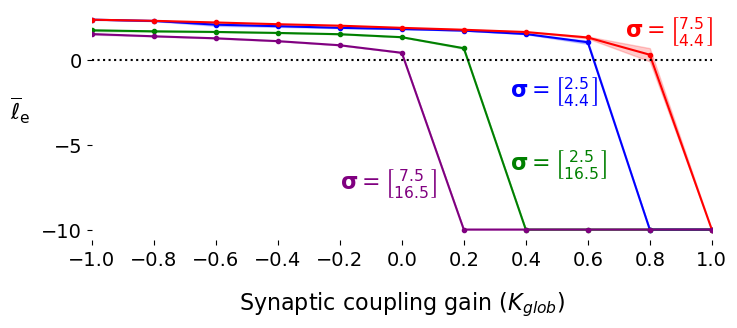

In [12]:
colors= ['b', 'g', 'r', 'purple']

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Karr, modLyapA_mean[k, :], ".-", color=colors[k])
    plt.fill_between(Karr, modLyapA_mean[k, :] - modLyapA_var[k, :], modLyapA_mean[k, :] + modLyapA_var[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic coupling gain $(K_{glob})$", fontsize=16, labelpad=15)
plt.xlim(min(Karr), max(Karr))
plt.xticks(Karr)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(0.35, -2.2, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(0.35, -6.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(0.72, 1.35, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(-0.2, -7.6, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootA, f"Imod_{params['i_mod']:.3f}mV_ModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

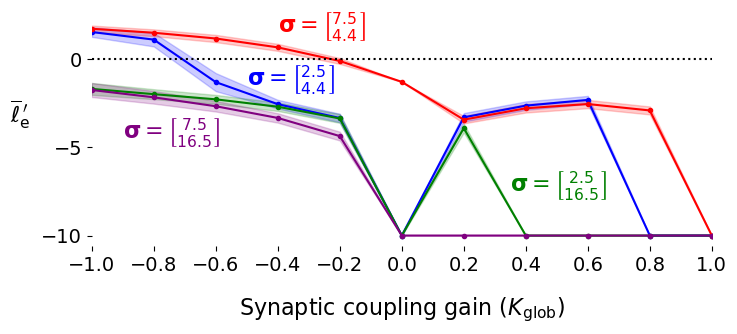

In [13]:
colors= ['b', 'g', 'r', 'purple']

nonModLyapAM = np.mean(nonmodLyapA_mean, axis=0)
nonModLyapAV = np.std(nonmodLyapA_mean, axis=0)

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Karr, nonModLyapAM[k, :], ".-", color=colors[k])
    plt.fill_between(Karr, nonModLyapAM[k, :] - nonModLyapAV[k, :], nonModLyapAM[k, :] + nonModLyapAV[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}^{\,\prime}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic coupling gain $(K_{\mathrm{glob}})$", fontsize=16, labelpad=15)
plt.xlim(min(Karr), max(Karr))
plt.xticks(Karr)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(-0.5, -1.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(0.35, -7.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(-0.4, 1.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(-0.9, -4.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootA, f"Imod_{params['i_mod']:.3f}mV_NonModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [14]:
fullLyapMeanA = np.zeros((nNodes, 4, len(Karr)))
fullLyapVarA = np.zeros((nNodes, 4, len(Karr)))

fullLyapMeanA[0, :, :] = modLyapA_mean
fullLyapMeanA[1:, :, :] = nonmodLyapA_mean

fullLyapVarA[0, :, :] = modLyapA_var
fullLyapVarA[1:, :, :] = nonmodLyapA_var

Text(0.02, 0.5, '$\\overline{\\ell}_{\\rm e}^{\\,\\prime}$')

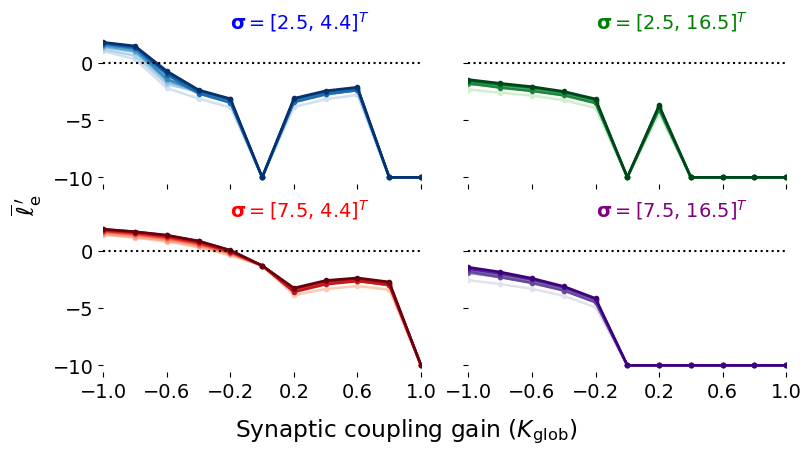

In [15]:
COLORS = ["Blues", "Greens", "Reds", "Purples"]
pSige = [2.5, 7.5]
pSigi = [4.4, 16.5]

fig, axes = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True, layout="constrained")
nRow = 0
k=0
for ne, sige in enumerate(pSige):
    nCol = 0
    for ni, sigi in enumerate(pSigi):
        _colors= plt.get_cmap(COLORS[k])
        colorIter = iter(_colors(np.linspace(0.2, 1, nNodes - 1 - 1)))
        for n in range(nNodes - 2, 0, -1):
            _color = next(colorIter)
            axes[nRow, nCol].plot(Karr, nonmodLyapA_mean[n, k, :], ".-", color=_color, linewidth=1.8)
            # axes[nRow, nCol].fill_between(Karr, nonmodLyapA_mean[n, k, :] - nonmodLyapA_var[n, k, :], 
            #                               nonmodLyapA_mean[n, k, :] + nonmodLyapA_var[n, k, :], color=_color, alpha=0.2)
        
        # axes[nRow, nCol].plot(Karr, nonModLyapAM[k, :], "--", color="white", linewidth=1.8)
        axes[nRow, nCol].axhline(y=0, linestyle=":", color="k")
        axes[nRow, nCol].set_xticks(Karr[::2])
        axes[nRow, nCol].text(-0.2, 3, r"$\mathbf{\sigma} = [$" + f"{sige}, {sigi}" + r"$]^T$", color=colors[k])
        axes[nRow, nCol].set_xlim(min(Karr), max(Karr))

        for pos in ["right", "left", "top", "bottom"]:
            axes[nRow, nCol].spines[pos].set_visible(False)
        nCol += 1
        k += 1
    nRow += 1

fig.supxlabel(r"Synaptic coupling gain $(K_{\rm glob})$", y=-0.1)
fig.supylabel(r"$\overline{\ell}_{\rm e}^{\,\prime}$")

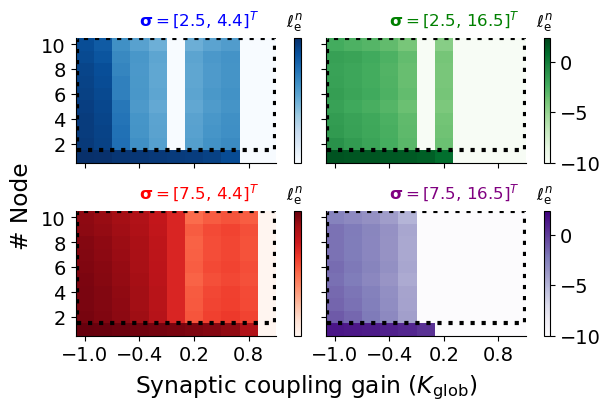

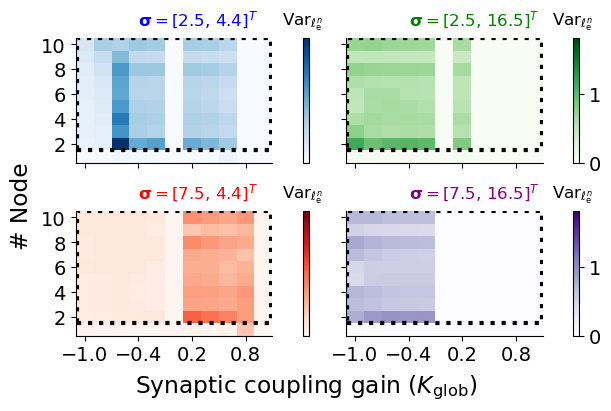

In [16]:
Ylabel=r"Synaptic coupling gain $(K_\mathrm{glob})$"
meanvarplot(fullLyapMeanA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1.5, variable = r"$\ell_{\rm e}^n$",
                figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_LyapMean.jpg")
meanvarplot(fullLyapVarA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=0.25, variable = r"$\mathrm{Var}_{\ell_{\rm e}^n}$",
                figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_LyapVar.jpg")

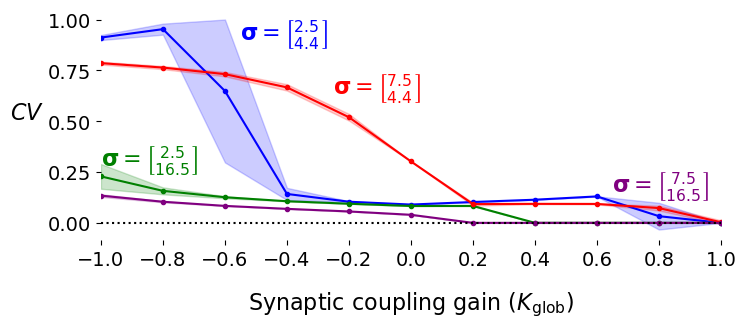

In [17]:
plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Karr, cvAMean[k, :], ".-", color=colors[k])
    plt.fill_between(Karr, cvAMean[k, :] - cvAVar[k, :], cvAMean[k, :] + cvAVar[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic coupling gain $(K_{\mathrm{glob}})$", fontsize=16, labelpad=15)
plt.xlim(min(Karr), max(Karr))
plt.xticks(Karr)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(-0.55, 0.9, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(-1, 0.28, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(-0.25, 0.63, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(0.65, 0.15, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootA, f"Imod_{params['i_mod']:.3f}mV_CV.jpg"), dpi=300, bbox_inches='tight')
plt.show()

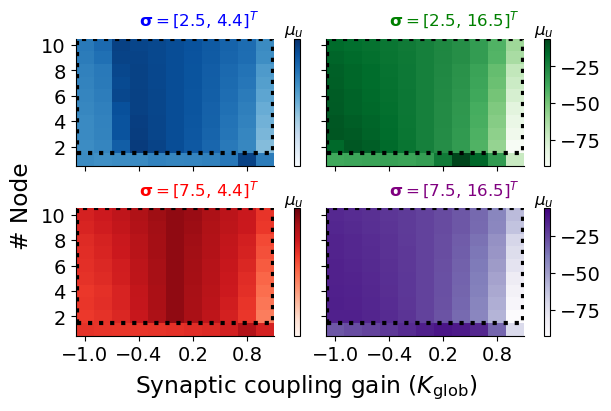

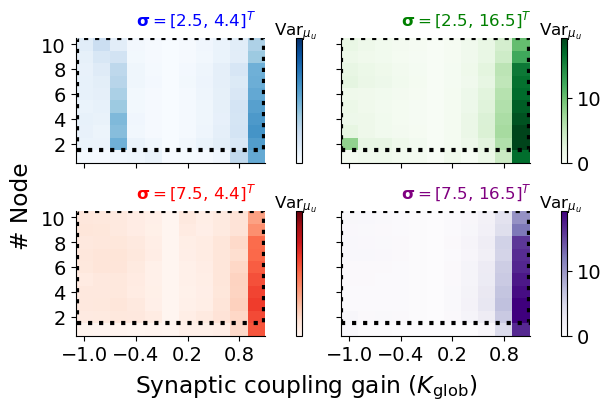

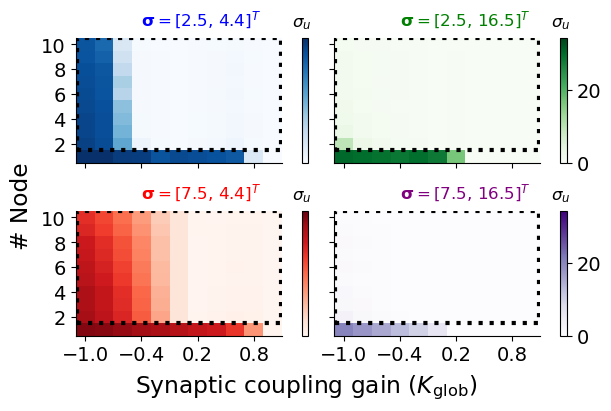

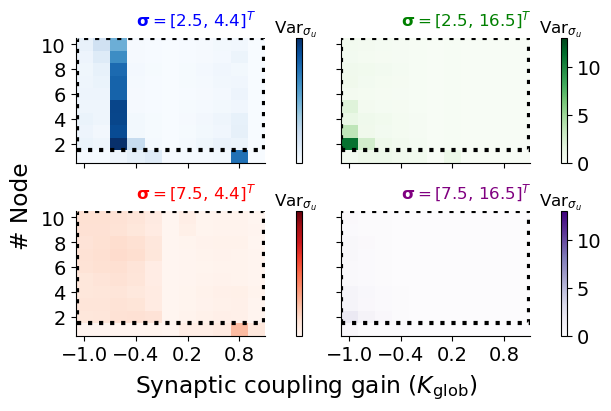

In [18]:
meanvarplot(MeanMeanA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=5, variable = r"$\mu_u$",
                figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_MeanNeural.jpg")
meanvarplot(VarMeanA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1, variable = r"$\mathrm{Var}_{\mu_u}$",
                figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_VarMeanNeural.jpg")
meanvarplot(MeanVarA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=4, variable = r"$\sigma_u$",
                figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_VarNeural.jpg")
meanvarplot(VarVarA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1, variable = r"$\mathrm{Var}_{\sigma_u}$",
                figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_VarVarNeural.jpg")

In [19]:
params['Kglob'] = -0.2
_results = glob.glob(os.path.join(loadA, f"*_KGlob_{params['Kglob']:.2f}_*"))
print(f"No. of files = {len(_results)}")

No. of files = 10


In [20]:
LyapIA, CVIA, Iarr_ = sort_filesI(_results)
modLyapIA_mean, modLyapIA_var, nonmodLyapIA_mean, nonmodLyapIA_var = lyapunov_plot_arr(LyapIA, Iarr_)
cvIAMean, cvIAVar, MeanMeanIA, MeanVarIA, VarMeanIA, VarVarIA = cv_plot_arr(CVIA, Iarr_)

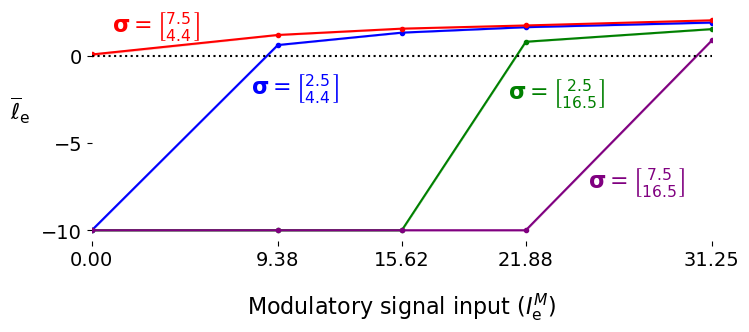

In [21]:
colors= ['b', 'g', 'r', 'purple']

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Iarr_, modLyapIA_mean[k, :], ".-", color=colors[k])
    plt.fill_between(Iarr_, modLyapIA_mean[k, :] - modLyapIA_var[k, :], modLyapIA_mean[k, :] + modLyapIA_var[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I_\mathrm{e}^M)$", fontsize=16, labelpad=15)
plt.xlim(min(Iarr_), max(Iarr_))
plt.xticks(Iarr_)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(8, -2.2, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(21, -2.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(1, 1.35, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(25, -7.6, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootA, f"KGlob_{params['Kglob']:.2f}_ModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

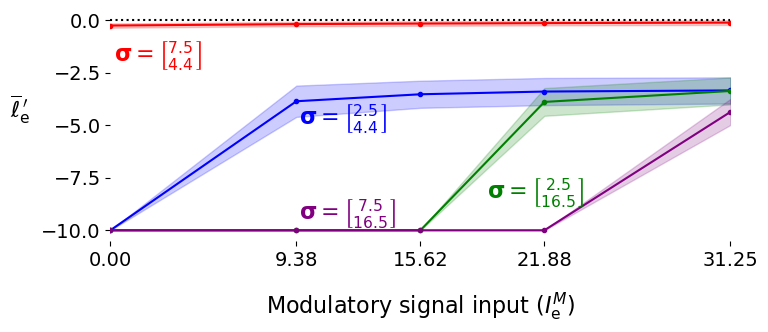

In [22]:
colors= ['b', 'g', 'r', 'purple']

nonModLyapIAM = np.mean(nonmodLyapIA_mean, axis=0)
nonModLyapIAV = np.mean(nonmodLyapIA_var, axis=0)

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Iarr_, nonModLyapIAM[k, :], ".-", color=colors[k])
    plt.fill_between(Iarr_, nonModLyapIAM[k, :] - nonModLyapIAV[k, :], nonModLyapIAM[k, :] + nonModLyapIAV[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}^{\,\prime}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^M_{\mathrm{e}})$", fontsize=16, labelpad=15)
plt.xlim(min(Iarr_), max(Iarr_))
plt.xticks(Iarr_)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(9.5, -5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(19, -8.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(0.2, -2, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(9.5, -9.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootA, f"KGlob_{params['Kglob']:.2f}_NonModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [23]:
fullLyapMeanIA = np.zeros((nNodes, 4, len(Iarr_)))
fullLyapVarIA = np.zeros((nNodes, 4, len(Iarr_)))

fullLyapMeanIA[0, :, :] = modLyapIA_mean
fullLyapMeanIA[1:, :, :] = nonmodLyapIA_mean

fullLyapVarIA[0, :, :] = modLyapIA_var
fullLyapVarIA[1:, :, :] = nonmodLyapIA_var

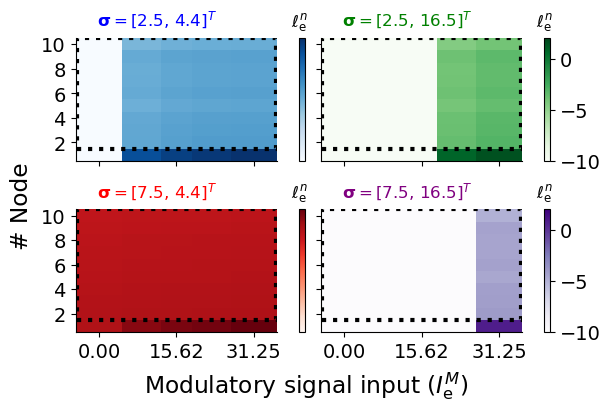

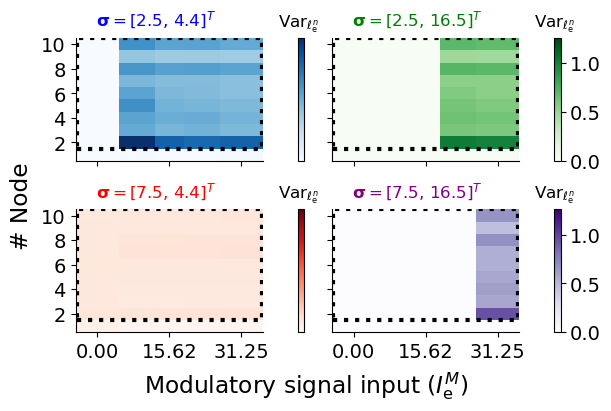

In [24]:
Ylabel=r"Modulatory signal input $(I^M_\mathrm{e})$"

meanvarplot(fullLyapMeanIA, figsize=(6,4), Xarr = Iarr_, Ylabel=Ylabel, offset=1.5, variable = r"$\ell_{\rm e}^n$", 
            figroot=figurerootA, filename=f"KGlob_{params['Kglob']:.2f}_LyapMean.jpg")
meanvarplot(fullLyapVarIA, figsize=(6,4), Xarr = Iarr_, Ylabel=Ylabel, offset=0.15, variable = r"$\mathrm{Var}_{\ell_{\rm e}^n}$", 
            figroot=figurerootA, filename=f"KGlob_{params['Kglob']:.2f}_LyapVar.jpg")

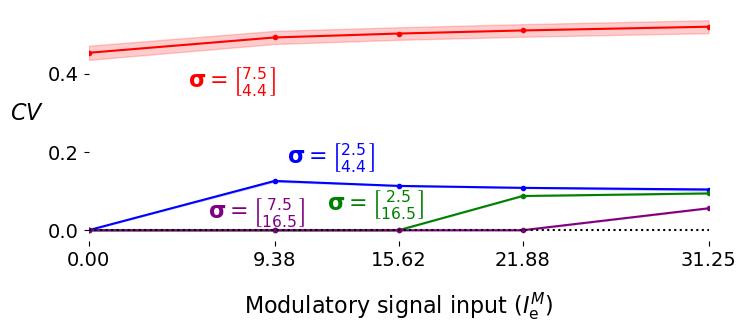

In [25]:
plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Iarr_, cvIAMean[k, :], ".-", color=colors[k])
    plt.fill_between(Iarr_, cvIAMean[k, :] - cvIAVar[k, :], cvIAMean[k, :] + cvIAVar[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^M_{\mathrm{e}})$", fontsize=16, labelpad=15)
plt.xlim(min(Iarr_), max(Iarr_))
plt.xticks(Iarr_)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(10, 0.17, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(12, 0.05, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(5, 0.362, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(6, 0.03, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootA, f"KGlob_{params['Kglob']:.2f}_CV.jpg"), dpi=300, bbox_inches='tight')
plt.show()

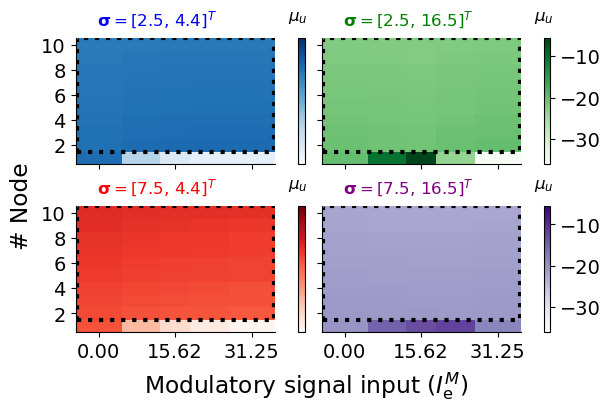

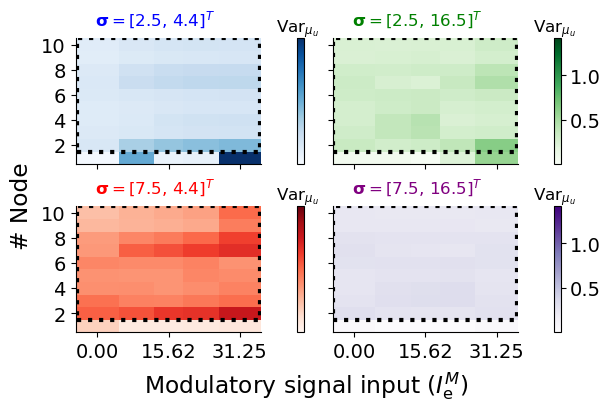

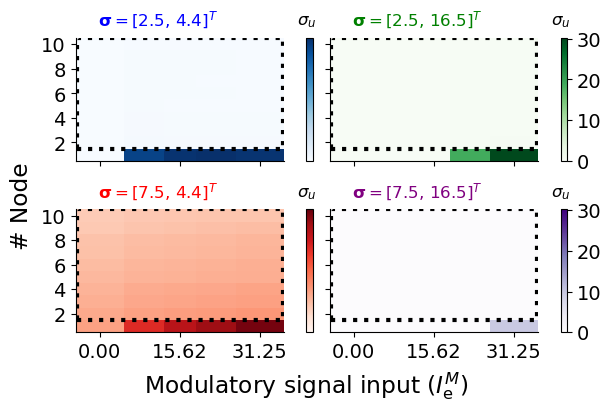

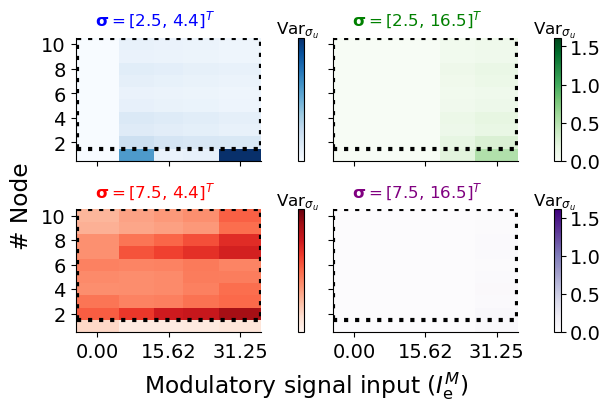

In [26]:
meanvarplot(MeanMeanIA, figsize=(6,4), Xarr=Iarr_, Ylabel=Ylabel, offset=5, variable = r"$\mu_u$",
                figroot=figurerootA, filename=f"KGlob_{params['Kglob']:.2f}_MeanNeural.jpg")
meanvarplot(VarMeanIA, figsize=(6,4), Xarr=Iarr_, Ylabel=Ylabel, offset=.1, variable = r"$\mathrm{Var}_{\mu_u}$",
                figroot=figurerootA, filename=f"KGlob_{params['Kglob']:.2f}_VarMeanNeural.jpg")
meanvarplot(MeanVarIA, figsize=(6,4), Xarr=Iarr_, Ylabel=Ylabel, offset=4, variable = r"$\sigma_u$",
                figroot=figurerootA, filename=f"KGlob_{params['Kglob']:.2f}_VarNeural.jpg")
meanvarplot(VarVarIA, figsize=(6,4), Xarr=Iarr_, Ylabel=Ylabel, offset=.1, variable = r"$\mathrm{Var}_{\sigma_u}$",
                figroot=figurerootA, filename=f"KGlob_{params['Kglob']:.2f}_VarVarNeural.jpg")

### Configuration B

In [27]:
rootB = "Setup_B3"
volatile_dir = "results/volatility"

save_str = datetime.datetime(2024, 5, 10)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadB = os.path.join("../", rootB, volatile_dir, sub_dir)

params['i_mod'] = modAmp[0]

figurerootB = "./results/volatility/ConfigureB"
os.makedirs(figurerootB, exist_ok=True)

In [28]:
_results = glob.glob(os.path.join(loadB, f"Imod_{params['i_mod']:.3f}mV*"))
print(f"No. of files = {len(_results)}")

No. of files = 22


In [29]:
LyapB, CVB, Karr = sort_filesK(_results)
modLyapB_mean, modLyapB_var, nonmodLyapB_mean, nonmodLyapB_var = lyapunov_plot_arr(LyapB, Karr)
cvBMean, cvBVar, MeanMeanB, MeanVarB, VarMeanB, VarVarB = cv_plot_arr(CVB, Karr)

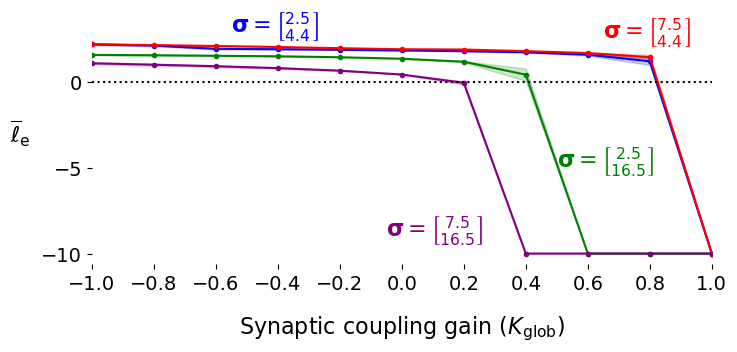

In [30]:
colors= ['b', 'g', 'r', 'purple']

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Karr, modLyapB_mean[k, :], ".-", color=colors[k])
    plt.fill_between(Karr, modLyapB_mean[k, :] - modLyapB_var[k, :], modLyapB_mean[k, :] + modLyapB_var[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic coupling gain $(K_{\mathrm{glob}})$", fontsize=16, labelpad=15)
plt.xlim(min(Karr), max(Karr))
plt.xticks(Karr)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(-0.55, 2.9, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(0.5, -5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(0.65, 2.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(-0.05, -9, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootB, f"Imod_{params['i_mod']:.3f}mV_ModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

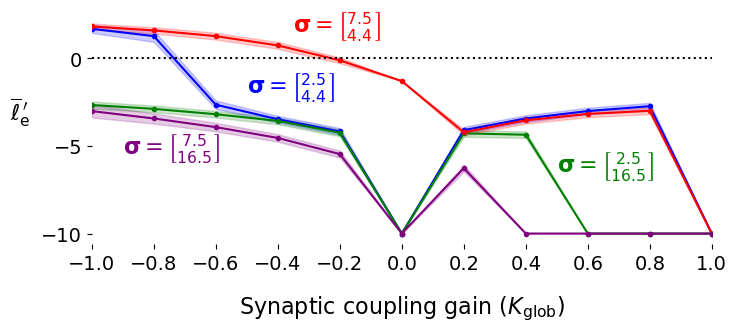

In [31]:
colors= ['b', 'g', 'r', 'purple']

nonModLyapBM = np.mean(nonmodLyapB_mean, axis=0)
nonModLyapBV = np.std(nonmodLyapB_mean, axis=0)

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Karr, nonModLyapBM[k, :], ".-", color=colors[k])
    plt.fill_between(Karr, nonModLyapBM[k, :] - nonModLyapBV[k, :], nonModLyapBM[k, :] + nonModLyapBV[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}^{\,\prime}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic coupling gain $(K_{\mathrm{glob}})$", fontsize=16, labelpad=15)
plt.xlim(min(Karr), max(Karr))
plt.xticks(Karr)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(-0.5, -2, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(0.5, -6.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(-0.35, 1.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(-0.9, -5.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootB, f"Imod_{params['i_mod']:.3f}mV_NonModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [32]:
fullLyapMeanB = np.zeros((nNodes, 4, len(Karr)))
fullLyapVarB = np.zeros((nNodes, 4, len(Karr)))

fullLyapMeanB[0, :, :] = modLyapB_mean
fullLyapMeanB[1:, :, :] = nonmodLyapB_mean

fullLyapVarB[0, :, :] = modLyapB_var
fullLyapVarB[1:, :, :] = nonmodLyapB_var

Text(0.02, 0.5, '$\\overline{\\ell}_{\\rm e}^{\\,\\prime}$')

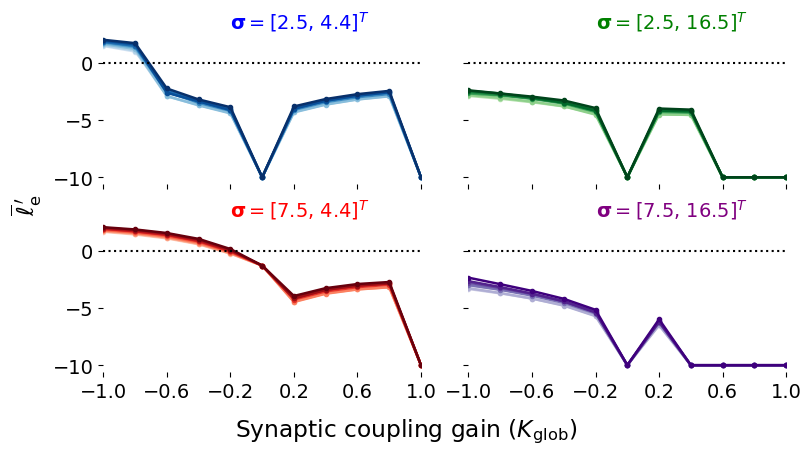

In [33]:
COLORS = ["Blues", "Greens", "Reds", "Purples"]
pSige = [2.5, 7.5]
pSigi = [4.4, 16.5]

fig, axes = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True, layout="constrained")
nRow = 0
k=0
for ne, sige in enumerate(pSige):
    nCol = 0
    for ni, sigi in enumerate(pSigi):
        _colors= plt.get_cmap(COLORS[k])
        colorIter = iter(_colors(np.linspace(0.2, 1, nNodes - 1 - 1)))
        for n in range(1, nNodes-1):
            _color = next(colorIter)
            axes[nRow, nCol].plot(Karr, nonmodLyapB_mean[n, k, :], ".-", color=_color, linewidth=1.8)
            # axes[nRow, nCol].fill_between(Karr, nonmodLyapB_mean[n, k, :] - nonmodLyapB_var[n, k, :], 
            #                               nonmodLyapB_mean[n, k, :] + nonmodLyapB_var[n, k, :], color=_color, alpha=0.2)
        
        # axes[nRow, nCol].plot(Karr, nonModLyapAM[k, :], "--", color="white", linewidth=1.8)
        axes[nRow, nCol].axhline(y=0, linestyle=":", color="k")
        axes[nRow, nCol].set_xticks(Karr[::2])
        axes[nRow, nCol].text(-0.2, 3, r"$\mathbf{\sigma} = [$" + f"{sige}, {sigi}" + r"$]^T$", color=colors[k])
        axes[nRow, nCol].set_xlim(min(Karr), max(Karr))

        for pos in ["right", "left", "top", "bottom"]:
            axes[nRow, nCol].spines[pos].set_visible(False)
        nCol += 1
        k += 1
    nRow += 1

fig.supxlabel(r"Synaptic coupling gain $(K_{\rm glob})$", y=-0.1)
fig.supylabel(r"$\overline{\ell}_{\rm e}^{\,\prime}$")

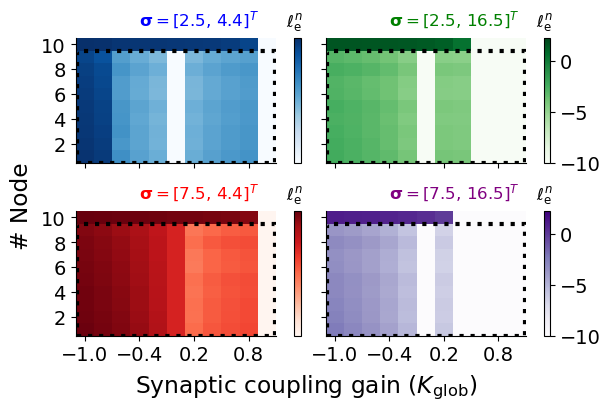

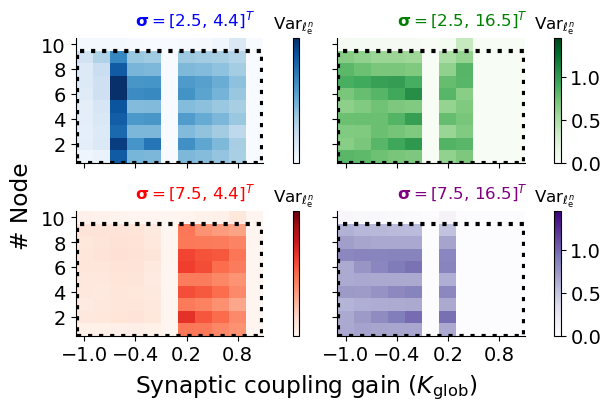

In [34]:
Ylabel=r"Synaptic coupling gain $(K_\mathrm{glob})$"
meanvarplot(fullLyapMeanB[::-1, :, :], M=0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1.5, variable = r"$\ell_{\rm e}^n$",
                figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_MeanLyap.jpg")
meanvarplot(fullLyapVarB[::-1, :, :], M=0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel,  offset=0.15, variable = r"$\mathrm{Var}_{\ell_{\rm e}^n}$",
                figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_VarLyap.jpg")

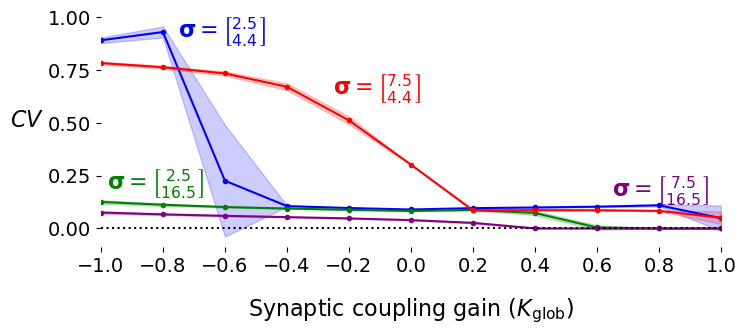

In [35]:
plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Karr, cvBMean[k, :], ".-", color=colors[k])
    plt.fill_between(Karr, cvBMean[k, :] - cvBVar[k, :], cvBMean[k, :] + cvBVar[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic coupling gain $(K_{\mathrm{glob}})$", fontsize=16, labelpad=15)
plt.xlim(min(Karr), max(Karr))
plt.xticks(Karr)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(-0.75, 0.9, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(-0.98, 0.18, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(-0.25, 0.63, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(0.65, 0.15, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootB, f"Imod_{params['i_mod']:.3f}mV_CV.jpg"), dpi=300, bbox_inches='tight')
plt.show()

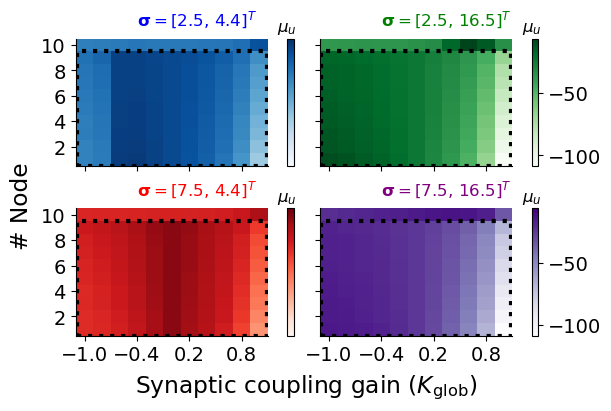

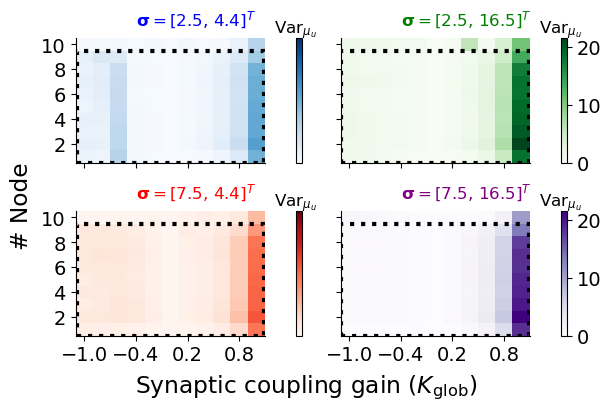

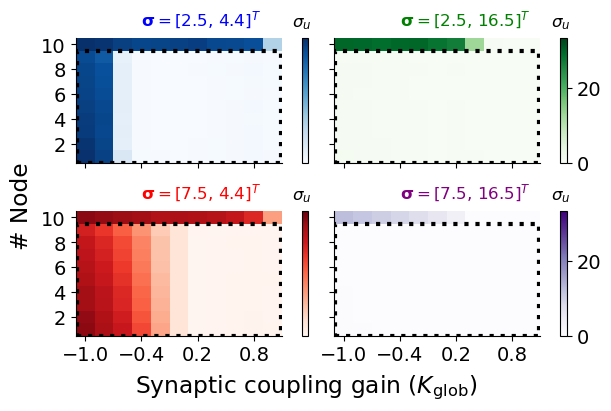

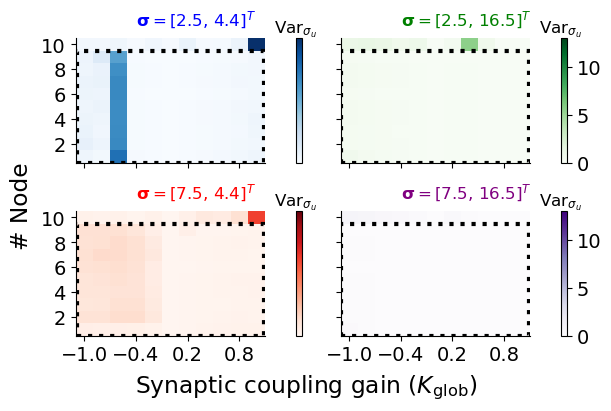

In [36]:
meanvarplot(MeanMeanB[::-1, :, :], M=0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=8, variable = r"$\mu_u$",
                figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_MeanNeural.jpg")
meanvarplot(VarMeanB[::-1, :, :], M=0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1.5, variable = r"$\mathrm{Var}_{\mu_u}$",
                figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_VarMeanNeural.jpg")
meanvarplot(MeanVarB[::-1, :, :], M=0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=4, variable = r"$\sigma_u$",
                figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_VarNeural.jpg")
meanvarplot(VarVarB[::-1, :, :], M=0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1, variable = r"$\mathrm{Var}_{\sigma_u}$",
                figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_VarVarNeural.jpg")

In [37]:
params['Kglob'] = -0.2
_results = glob.glob(os.path.join(loadB, f"*_KGlob_{params['Kglob']:.2f}_*"))
print(f"No. of files = {len(_results)}")

No. of files = 10


In [38]:
LyapIB, CVIB, Iarr_ = sort_filesI(_results)
modLyapIB_mean, modLyapIB_var, nonmodLyapIB_mean, nonmodLyapIB_var = lyapunov_plot_arr(LyapIB, Iarr_)
cvIBMean, cvIBVar, MeanMeanIB, MeanVarIB, VarMeanIB, VarVarIB = cv_plot_arr(CVIB, Iarr_)

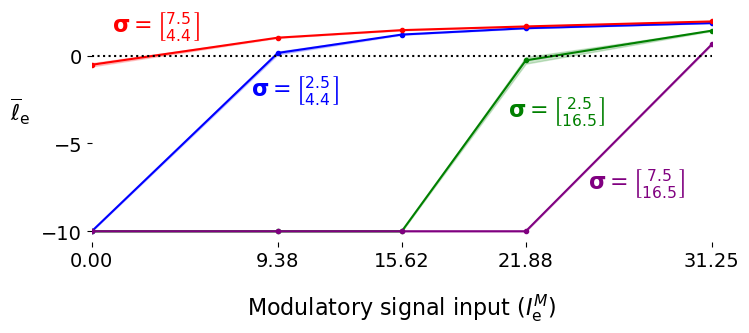

In [39]:
colors= ['b', 'g', 'r', 'purple']

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Iarr_, modLyapIB_mean[k, :], ".-", color=colors[k])
    plt.fill_between(Iarr_, modLyapIB_mean[k, :] - modLyapIB_var[k, :], modLyapIB_mean[k, :] + modLyapIB_var[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I_\mathrm{e}^M)$", fontsize=16, labelpad=15)
plt.xlim(min(Iarr_), max(Iarr_))
plt.xticks(Iarr_)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(8, -2.3, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(21, -3.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(1, 1.35, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(25, -7.6, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootB, f"KGlob_{params['Kglob']:.2f}_ModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

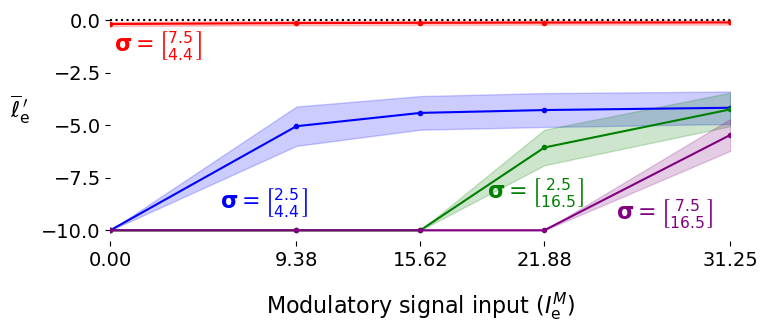

In [40]:
colors= ['b', 'g', 'r', 'purple']

nonModLyapIBM = np.mean(nonmodLyapIB_mean, axis=0)
nonModLyapIBV = np.mean(nonmodLyapIB_var, axis=0)

plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Iarr_, nonModLyapIBM[k, :], ".-", color=colors[k])
    plt.fill_between(Iarr_, nonModLyapIBM[k, :] - nonModLyapIBV[k, :], nonModLyapIBM[k, :] + nonModLyapIBV[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_{\rm e}^{\,\prime}$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^M_{\mathrm{e}})$", fontsize=16, labelpad=15)
plt.xlim(min(Iarr_), max(Iarr_))
plt.xticks(Iarr_)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(5.5, -9, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(19, -8.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(0.2, -1.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(25.5, -9.5, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootB, f"KGlob_{params['Kglob']:.2f}_NonModLyap.jpg"), dpi=300, bbox_inches='tight')
plt.show()

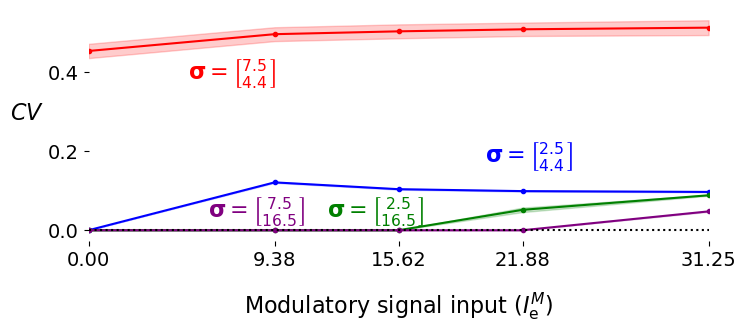

In [41]:
plt.figure(figsize=(8, 3))
for k in range(4):
    plt.plot(Iarr_, cvIBMean[k, :], ".-", color=colors[k])
    plt.fill_between(Iarr_, cvIBMean[k, :] - cvIBVar[k, :], cvIBMean[k, :] + cvIBVar[k, :], color=colors[k], alpha=0.2)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^M_{\mathrm{e}})$", fontsize=16, labelpad=15)
plt.xlim(min(Iarr_), max(Iarr_))
plt.xticks(Iarr_)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.text(20, 0.17, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
plt.text(12, 0.03, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
plt.text(5, 0.38, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
plt.text(6, 0.03, r'$\mathbf{\sigma} =  \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

plt.savefig(os.path.join(figurerootB, f"KGlob_{params['Kglob']:.2f}_CV.jpg"), dpi=300, bbox_inches='tight')
plt.show()

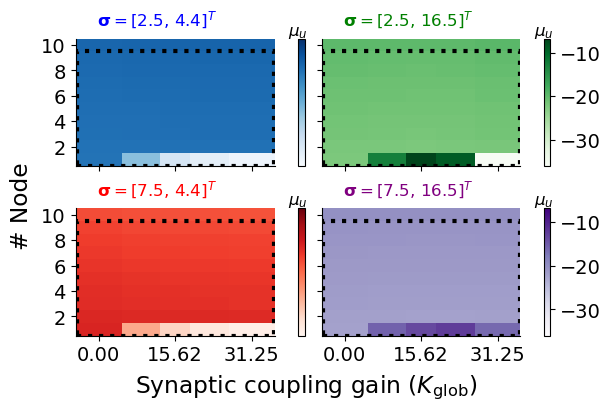

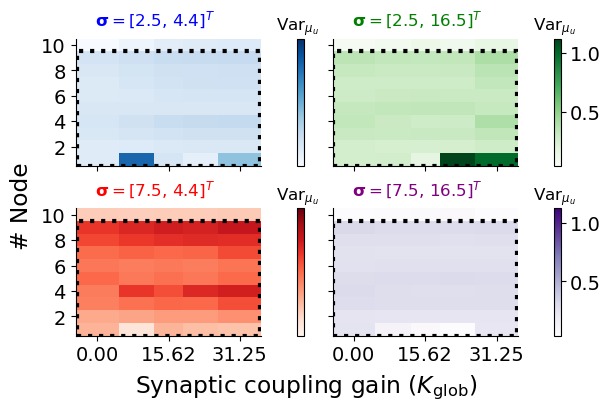

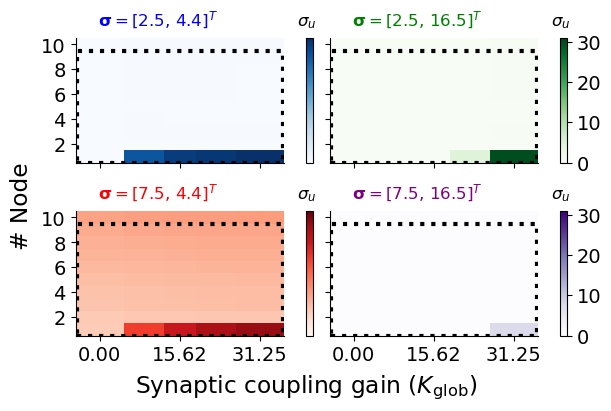

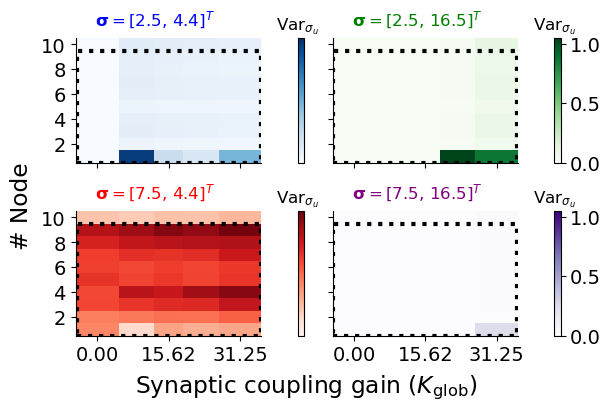

In [42]:
meanvarplot(MeanMeanIB, figsize=(6,4), M=0, Xarr=Iarr_, Ylabel=Ylabel, offset=1.5, variable = r"$\mu_u$",
                figroot=figurerootB, filename=f"KGlob_{params['Kglob']:.2f}_MeanNeural.jpg")
meanvarplot(VarMeanIB, figsize=(6,4), M=0, Xarr=Iarr_, Ylabel=Ylabel, offset=.1, variable = r"$\mathrm{Var}_{\mu_u}$",
                figroot=figurerootB, filename=f"KGlob_{params['Kglob']:.2f}_VarMeanNeural.jpg")
meanvarplot(MeanVarIB, figsize=(6,4), M=0, Xarr=Iarr_, Ylabel=Ylabel, offset=4, variable = r"$\sigma_u$",
                figroot=figurerootB, filename=f"KGlob_{params['Kglob']:.2f}_VarNeural.jpg")
meanvarplot(VarVarIB, figsize=(6,4), M=0, Xarr=Iarr_, Ylabel=Ylabel, offset=.1, variable = r"$\mathrm{Var}_{\sigma_u}$",
                figroot=figurerootB, filename=f"KGlob_{params['Kglob']:.2f}_VarVarNeural.jpg")

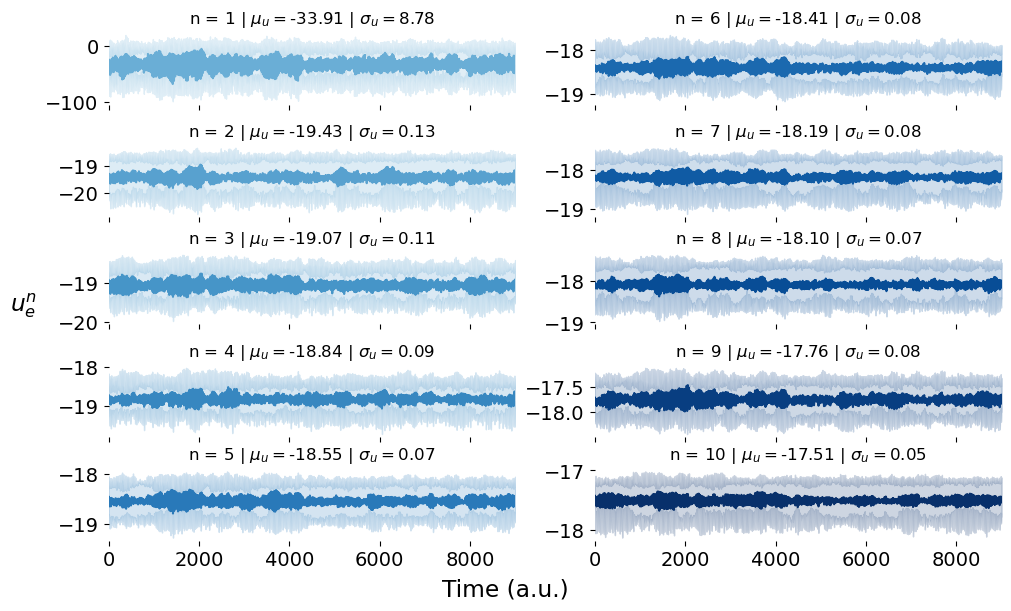

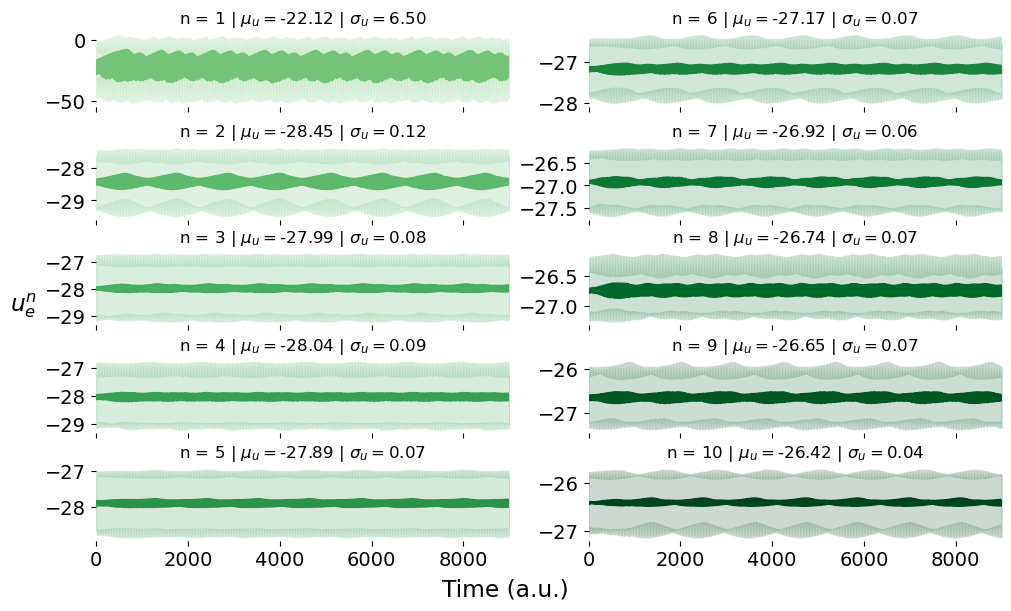

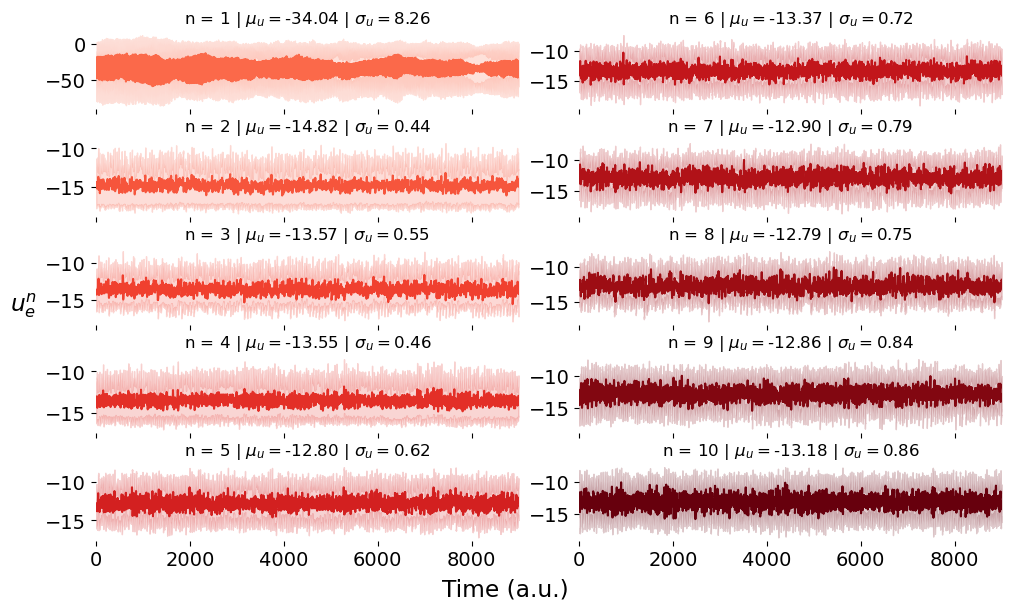

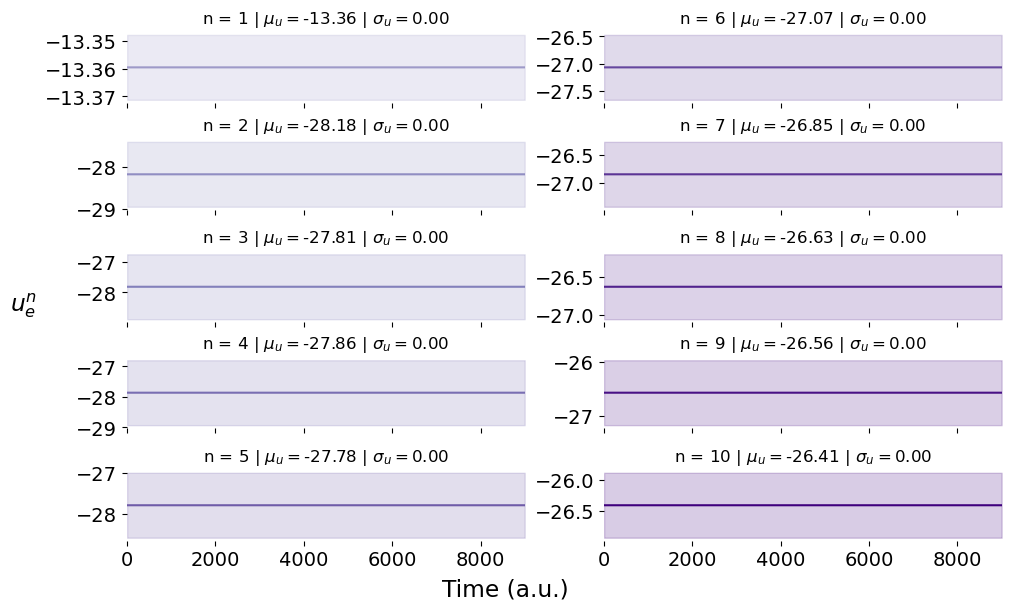

In [53]:
# Setting parameters to for the modeling
P, ROI = modelP(N = nNodes, nTrials = nRealizations, WD = "High")
Dnet= np.zeros((nNodes, 2 * nNodes))

for n in range(nNodes):
    Dnet[n, 2 * n : 2 * n + 2] = np.array([1, 0])

Abar = np.zeros((nRealizations, 2 * nNodes, 2 * nNodes))
for q in range(nRealizations):
    Abar[q] = (Dnet.T @ P[q]) @ Dnet

params["Abar"] = Abar 

tau = np.diag(np.array([1 / params['tau_e'], 1 / params['tau_i']]))
params['Tau'] = Tau = np.kron(np.eye(nNodes), tau)

w = np.array([[params['wee'], params['wie']], [params['wei'], params['wii']]])
params['W'] = W = np.kron(np.eye(nNodes), w)

ibias = np.array([params['i_ebias'], params['i_ibias']])
params['i_bias'] = i_bias = np.repeat(ibias[np.newaxis,...], nNodes, axis=0).flatten().reshape(-1, 1)

# Initialization
np.random.seed(1)
xInit = np.random.uniform(minval, maxval, (nTrials, 2 * nNodes))
# xInit = np.zeros((nTrials, 2 * nNodes))

modNodes = [0]
params['i_mod'] = 0.5 / params['gamma']

sige = [2.5, 8.5]
sigi = [4.4, 16.5]

Karr = [0.2]

colorPalets = ['Blues', 'Greens', 'Reds', 'Purples']
for K in Karr:
    params['Kglob'] = K
    permuteN = 0
    sigCov = 0.1 * np.eye(2)
    for sE in sige:
        for sI in sigi:
            params['sigma'] = np.zeros((nTrials, 2 * nNodes))

            sigMean = np.array([sE, sI])
            for q in range(nTrials):
                np.random.seed(q * 10 + 5)
                sigmaNet = np.random.multivariate_normal(sigMean, sigCov, nNodes)
                sigmaNet[modNodes, :] = sigMean

                params['sigma'][q, :] = abs(sigmaNet.flatten())
            # params['sigma'] = np.ones(2 * nNodes)
            # params['sigma'][0::2] = sE
            # params['sigma'][1::2] = sI

            # Running simulation
            u = np.zeros((nTrials, 2 * nNodes, T))
            u = euler_intergrate(u, xInit, modNodes = modNodes, **params)

            meanDynamics = np.mean(u[:, :, t_start:], axis=0)
            stdDynamics = np.std(u[:, :, t_start:], axis=0)

            _colors= plt.get_cmap(colorPalets[permuteN])
            colorIter = iter(_colors(np.linspace(0.5, 1, nNodes)))
            fig, axes = plt.subplots(5, 2, sharex=True, figsize=(10, 6), layout="constrained")

            nRow = 0
            nCol = 0

            for k in range(0, nNodes):
                color = next(colorIter)
                axes[nRow, nCol].plot(time_[:-t_start], meanDynamics[2 * k, :], color=color)
                axes[nRow, nCol].fill_between(time_[:-t_start], meanDynamics[2 * k, :] - stdDynamics[2 * k, :], 
                                            meanDynamics[2 * k, :] + stdDynamics[2 * k, :], color=color, alpha=0.2)
                axes[nRow, nCol].set_xlim(0, T - t_start)
                axes[nRow, nCol].set_title(f"n = {k + 1:01d} | " + r"$\mu_u = $"+f"{np.mean(meanDynamics[2 * k, :]):.2f} | " + r"$\sigma_u = $" + f"{np.std(meanDynamics[2 * k, :]):.2f}", fontsize=12)
                
                for pos in ["right", "left", "top", "bottom"]:
                    axes[nRow, nCol].spines[pos].set_visible(False)

                nRow += 1

                if nRow == 5:
                    nCol += 1
                    nRow = 0

            fig.supylabel(r"$u^n_e$", rotation=0)
            fig.supxlabel('Time (a.u.)')
            plt.savefig(os.path.join(figurerootB, f"Imod_{params['i_mod']:.3f}mV_Kglob_{K:.1f}_Sige_{sE:.1f}_Sigi_{sI:.1f}L.jpg"), dpi=300, bbox_inches='tight')
            plt.show()

            permuteN += 1


In [44]:
# # Setting parameters to for the modeling
# P, ROI = modelP(N = nNodes, nTrials = nRealizations, WD = "High")
# Dnet= np.zeros((nNodes, 2 * nNodes))

# for n in range(nNodes):
#     Dnet[n, 2 * n : 2 * n + 2] = np.array([1, 0])

# Abar = np.zeros((nRealizations, 2 * nNodes, 2 * nNodes))
# for q in range(nRealizations):
#     Abar[q] = (Dnet.T @ P[q]) @ Dnet

# params["Abar"] = Abar 

# tau = np.diag(np.array([1 / params['tau_e'], 1 / params['tau_i']]))
# params['Tau'] = Tau = np.kron(np.eye(nNodes), tau)

# w = np.array([[params['wee'], params['wie']], [params['wei'], params['wii']]])
# params['W'] = W = np.kron(np.eye(nNodes), w)

# ibias = np.array([params['i_ebias'], params['i_ibias']])
# params['i_bias'] = i_bias = np.repeat(ibias[np.newaxis,...], nNodes, axis=0).flatten().reshape(-1, 1)

# # Initialization
# np.random.seed(0)
# xInit = np.random.uniform(minval, maxval, (nTrials, 2 * nNodes))

# modNodes = [0]
# params['i_mod'] = 0.5 / params['gamma']

# sige = [2.5, 7.5]
# sigi = [4.4, 16.5]

# Karr = [-0.6, 0.6]

# colorPalets = ['Blues', 'Greens', 'Reds', 'Purples']
# for K in Karr:
#     params['Kglob'] = K
#     permuteN = 0
#     for sE in sige:
#         for sI in sigi:
#             params['sigma'] = np.ones(2 * nNodes)
#             params['sigma'][0::2] = sE
#             params['sigma'][1::2] = sI

#             # Running simulation
#             u = np.zeros((nTrials, 2 * nNodes, T))
#             u = euler_intergrate(u, xInit, modNodes = modNodes, **params)

#             meanDynamics = np.mean(u[:, :, t_start:], axis=0)
#             stdDynamics = np.std(u[:, :, t_start:], axis=0) 

#             _colors= plt.get_cmap(colorPalets[permuteN])
#             colorIter = iter(_colors(np.linspace(0.5, 1, nNodes)))
#             fig, axes = plt.subplots(5, 2, sharey=True, sharex=True, figsize=(10, 6), layout="constrained")

#             nRow = 0
#             nCol = 0

#             for k in range(0, nNodes):
#                 color = next(colorIter)
#                 axes[nRow, nCol].plot(time_[:-t_start], meanDynamics[2 * k, :], color=color)
#                 axes[nRow, nCol].fill_between(time_[:-t_start], meanDynamics[2 * k, :] - stdDynamics[2 * k, :], 
#                                             meanDynamics[2 * k, :] + stdDynamics[2 * k, :], color=color, alpha=0.2)

#                 axes[nRow, nCol].set_xlim(0, T - t_start)
#                 axes[nRow, nCol].set_title(f"n = {k + 1:01d} | " + r"$\mu_u = $"+f"{np.mean(meanDynamics[2 * k, :]):.2f} | " + r"$\sigma_u = $" + f"{np.std(meanDynamics[2 * k, :]):.2f}", fontsize=12)
                
#                 for pos in ["right", "left", "top", "bottom"]:
#                     axes[nRow, nCol].spines[pos].set_visible(False)

#                 nRow += 1

#                 if nRow == 5:
#                     nCol += 1
#                     nRow = 0

#             fig.supylabel(r"$u^n_e$", rotation=0)
#             fig.supxlabel('Time (a.u.)')
#             plt.savefig(os.path.join(figurerootA, f"Imod_{params['i_mod']:.3f}mV_Kglob_{K:.1f}_Sige_{sE:.1f}_Sigi_{sI:.1f}H.jpg"), dpi=300, bbox_inches='tight')
#             plt.show()

#             permuteN += 1


In [45]:
P, ROI = modelP(N = nNodes, nTrials = nRealizations, WD = "High")
Degrees = np.sum(P, axis=2)
MeanDegree = np.mean(Degrees, axis=0)
VarDegree = np.std(Degrees, axis=0)

Text(0, 0.5, '$\\mathrm{D}^n$')

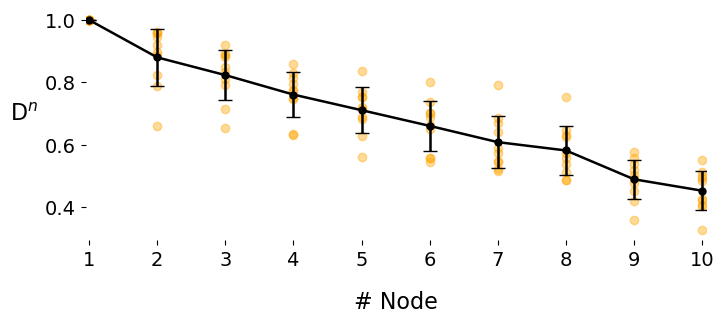

In [46]:
plt.figure(figsize=(8, 3))
plt.errorbar(np.arange(1, 11), MeanDegree, VarDegree, fmt="o-", color='k', linewidth=1.8, markersize=5, capsize=5)
for k in range(nRealizations):
    plt.scatter(np.arange(1, 11), Degrees[k, :], color="orange", alpha=0.4)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.xticks(np.arange(1, 11))
plt.xlim(.95, 10.05)
plt.xlabel("# Node", labelpad=15, fontsize=16)
plt.ylabel(r"$\mathrm{D}^n$", rotation=0, labelpad=15, fontsize=16)

Text(0, 0.5, '$p_n$')

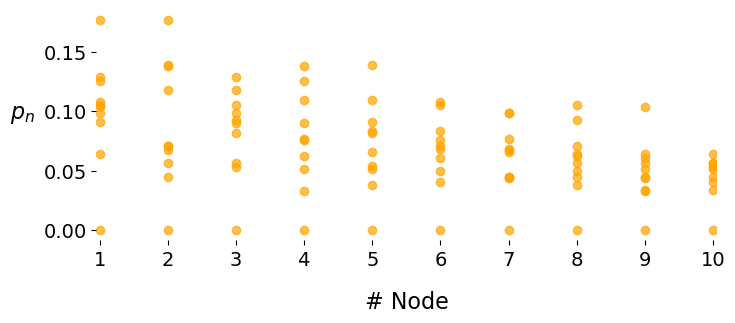

In [47]:
DegreesDist = np.mean(P, axis=0)

plt.figure(figsize=(8, 3))
for k in range(nRealizations):
    plt.scatter(np.arange(1, 11), DegreesDist[k, :], color="orange", alpha=0.7)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.xticks(np.arange(1, 11))
plt.xlim(.95, 10.05)
plt.xlabel("# Node", labelpad=15, fontsize=16)
plt.ylabel(r"$p_n$", rotation=0, labelpad=15, fontsize=16)

Text(0, 0.5, '$\\mathcal{C}_{p_{nm}}$')

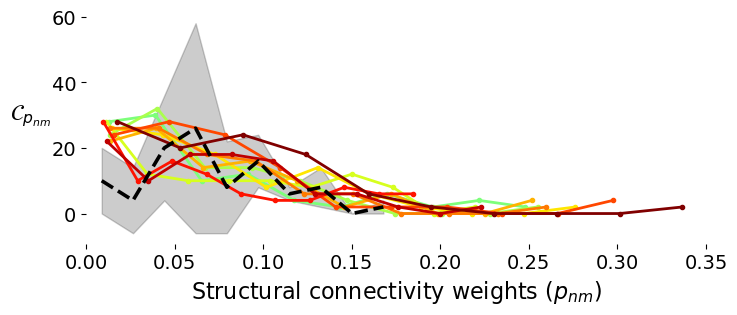

In [48]:
meanWeights = np.mean(P, axis=0)
stdWeights = np.std(P, axis=0)

plt.figure(figsize=(8,3))
_colors= plt.get_cmap("jet")
colorIter = iter(_colors(np.linspace(0.5, 1, nNodes)))

for i in range(10):
    count, bins = np.histogram(P[i, :, :].flatten(), bins=10)
    plt.plot((bins[:-1] + bins[1:])/2, count, '.-', linewidth=2, color=next(colorIter))

countM, binsM = np.histogram(meanWeights.flatten(), bins=10)
plt.plot((binsM[:-1] + binsM[1:])/2, countM, "k--", linewidth=2.6)

countS, binsS = np.histogram(stdWeights.flatten(), bins=10)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.fill_between((binsM[:-1] + binsM[1:])/2, countM - countS, countM + countS, color='k', alpha=0.2)
plt.xlim(0, 0.35)
plt.xlabel(r"Structural connectivity weights $(p_{nm})$", fontsize=16)
plt.ylabel(r"$\mathcal{C}_{p_{nm}}$", rotation=0, labelpad=15, fontsize=16)

